In [1]:
from RamanModel import *
from HelperFunctions import *
from Plots import *

In [2]:
def knnFit_persistent(samples, base_parameters, target_x, target_y, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    for _ in range(4):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    for r in range(rounds):
        # We don't reset heap here anymore!

        for _ in range(samples):
            current_y = np.zeros(len(target_x))
            current_params = []

            for i in range(4):
                p = peak_search_spaces[i]
                c = np.random.uniform(p["center_range"][0], p["center_range"][1])
                a = np.random.uniform(p["amplitude_range"][0], p["amplitude_range"][1])
                g = np.random.uniform(p["gamma_range"][0], p["gamma_range"][1])

                current_y += lorentzian(target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            if np.max(current_y) > 0:
                current_y /= np.max(current_y)

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, current_params))

        # --- DBSCAN-Style Clustering with Origin Tracking ---
        nearest_neighbors = [item[1] for item in heap]
        #print(nearest_neighbors)

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # CRITICAL CHECK: Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                # Mark peaks in this cluster as visited
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:4]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

            print(f"Round {r+1}: Peak {p_idx} search space narrowed (Agreed by {len(curves_in_cluster)} unique curves)")

        best_neighbor_params = nearest_neighbors[0]
        print(f"Round {r+1} Best Distance: {-heap[0][0]:.4f}")

    return best_neighbor_params, nearest_neighbors

Round 1: Peak 0 search space narrowed (Agreed by 1 unique curves)
Round 1 Best Distance: 19.8959
Round 2: Peak 0 search space narrowed (Agreed by 1 unique curves)
Round 2 Best Distance: 19.7611
Round 3: Peak 0 search space narrowed (Agreed by 1 unique curves)
Round 3: Peak 1 search space narrowed (Agreed by 1 unique curves)
Round 3 Best Distance: 19.6581
Round 4: Peak 0 search space narrowed (Agreed by 1 unique curves)
Round 4: Peak 1 search space narrowed (Agreed by 1 unique curves)
Round 4: Peak 2 search space narrowed (Agreed by 1 unique curves)
Round 4 Best Distance: 19.5822
Round 5: Peak 0 search space narrowed (Agreed by 3 unique curves)
Round 5: Peak 1 search space narrowed (Agreed by 3 unique curves)
Round 5: Peak 2 search space narrowed (Agreed by 3 unique curves)
Round 5: Peak 3 search space narrowed (Agreed by 3 unique curves)
Round 5 Best Distance: 19.5065
Round 6: Peak 0 search space narrowed (Agreed by 5 unique curves)
Round 6: Peak 1 search space narrowed (Agreed by 5 un

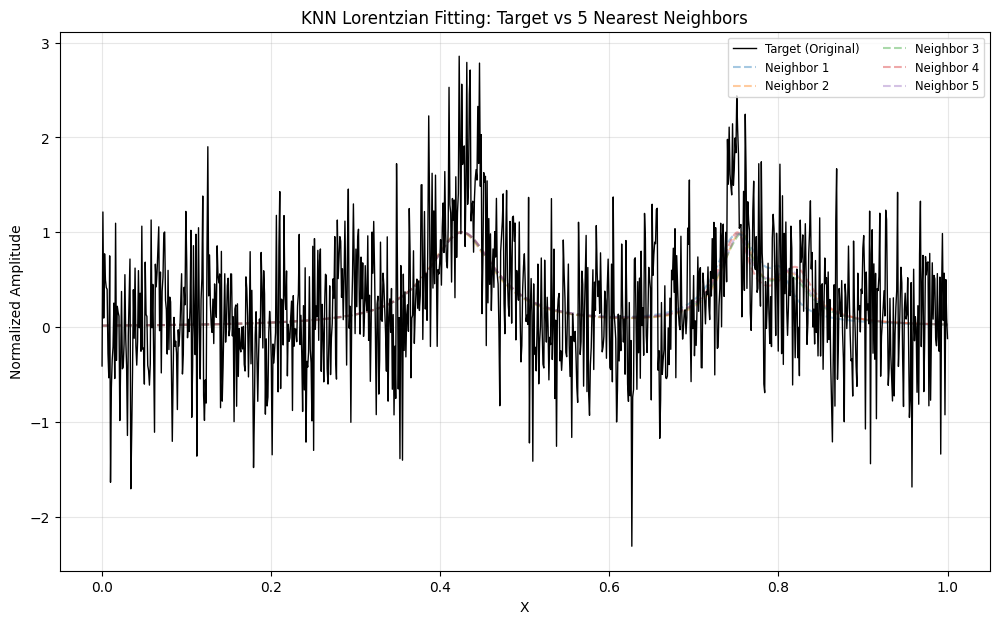

In [3]:
import matplotlib.pyplot as plt

# --- 1. Generate the "Target" Curve ---
parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1.0),
    "gamma_range": (0.01, 0.05),
    "x_min": 0,
    "x_max": 1
}

# Generate a target with 4 peaks and some noise
target_x, target_y, target_params = generateCurve(parameters, 4, 1000, 0.6)

# --- 2. Run the KnnFit ---
# We'll use 500 samples per round, k=10, for 3 rounds.
best_params, neighbors_params = knnFit_persistent(
    samples=10000,
    base_parameters=parameters,
    target_x=target_x,
    target_y=target_y,
    k=5,
    rounds=7,
    eps=0.15
)


PlotNeighbors(best_params, neighbors_params, target_x, target_y)


In [4]:

# Print comparison for the first found peak as an example
print("\nFinal Parameters of Best Fit (Neighbor 1):")
for i, p in enumerate(best_params):
    print(f"Peak {i}: Center={p['center']:.4f}, Amp={p['amplitude']:.4f}, Gamma={p['gamma']:.4f}")

print("\n\n")
print_peak_params(target_params)


Final Parameters of Best Fit (Neighbor 1):
Peak 0: Center=0.4257, Amp=0.7804, Gamma=0.0487
Peak 1: Center=0.8020, Amp=0.2718, Gamma=0.0148
Peak 2: Center=0.7447, Amp=0.4438, Gamma=0.0281
Peak 3: Center=0.7620, Amp=0.3536, Gamma=0.0301




Generated Curve Parameters:
-------------------------------------------------------
Peak ID    | Center       | Amplitude    | Gamma       
-------------------------------------------------------
0          | 0.2915       | 0.2156       | 0.0161      
1          | 0.4323       | 0.8282       | 0.0306      
2          | 0.7572       | 0.2835       | 0.0473      
3          | 0.7472       | 0.6071       | 0.0101      
-------------------------------------------------------



In [ ]:
def get_final_parameters(best_neighbor, nearest_neighbors, base_parameters, k, eps=0.15):
    """
    Calculates the consensus parameters by averaging clustered peaks.
    Falls back to the best_neighbor's peaks if no cluster is found.
    """
    # 1. Flatten all peaks and track origin
    all_candidate_peaks = []
    for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
        for peak in neighbor_params:
            all_candidate_peaks.append({
                "data": peak,
                "origin_curve": neighbor_id
            })

    visited = [False] * len(all_candidate_peaks)
    final_params = []
    found_clusters = []

    # 2. Identify clusters (same logic as knnFit)
    for i in range(len(all_candidate_peaks)):
        if visited[i]: continue

        cluster_indices = [i]
        curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

        for j in range(len(all_candidate_peaks)):
            if i == j: continue
            dist = get_param_distance(all_candidate_peaks[i]["data"],
                                    all_candidate_peaks[j]["data"],
                                    base_parameters)
            if dist < eps:
                cluster_indices.append(j)
                curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

        if len(curves_in_cluster) >= (k // 2):
            found_clusters.append(cluster_indices)
            for idx in cluster_indices:
                visited[idx] = True

    # 3. Sort clusters by center position to maintain order
    found_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

    # 4. Build the final 4-peak model
    # We compare found clusters against the best_neighbor's peaks
    # to fill in any missing slots.

    # Sort best_neighbor by center for consistent mapping
    best_neighbor_sorted = sorted(best_neighbor, key=lambda x: x['center'])

    for i in range(4):
        if i < len(found_clusters):
            # Calculate the Mean of the cluster
            indices = found_clusters[i]
            avg_center = np.mean([all_candidate_peaks[idx]['data']['center'] for idx in indices])
            avg_amplitude = np.mean([all_candidate_peaks[idx]['data']['amplitude'] for idx in indices])
            avg_gamma = np.mean([all_candidate_peaks[idx]['data']['gamma'] for idx in indices])

            final_params.append({
                "center": avg_center,
                "amplitude": avg_amplitude,
                "gamma": avg_gamma,
                "status": "clustered_mean"
            })
        else:
            # Fallback: Pick from the best individual curve found
            fallback_peak = best_neighbor_sorted[i].copy()
            fallback_peak["status"] = "fallback_best"
            final_params.append(fallback_peak)

    return final_params

In [ ]:
final_model_params = get_final_parameters(best_params, neighbors_params, parameters, k=5)

# Generate the final consensus curve for visualization
final_y = np.zeros(len(target_x))
for p in final_model_params:
    final_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
final_y /= np.max(final_y)

plt.plot(target_x, final_y, label="Consensus Mean Curve", color='red', linewidth=2)

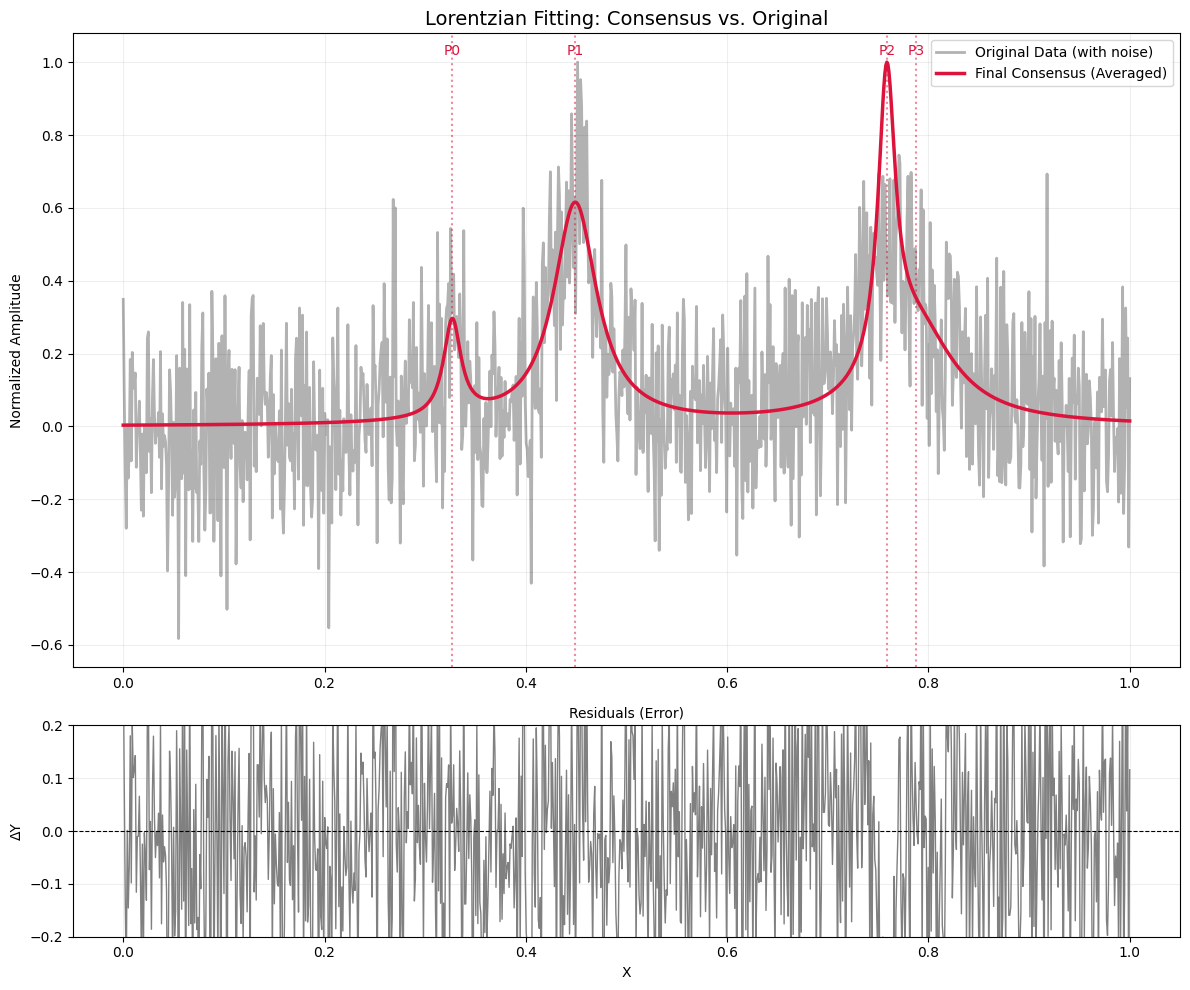

In [ ]:
def plot_final_comparison(target_x, target_y, final_params):
    # 1. Generate the curve from the averaged consensus parameters
    consensus_y = np.zeros(len(target_x))
    for p in final_params:
        consensus_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])

    # 2. Normalize to match target scale
    if np.max(consensus_y) > 0:
        consensus_y /= np.max(consensus_y)

    # 3. Create the visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Top Plot: Data Comparison
    ax1.plot(target_x, target_y, color='black', alpha=0.3, label='Original Data (with noise)', linewidth=2)
    ax1.plot(target_x, consensus_y, color='crimson', label='Final Consensus (Averaged)', linewidth=2.5)

    # Draw vertical lines at the calculated centers for clarity
    for i, p in enumerate(final_params):
        ax1.axvline(p['center'], color='crimson', linestyle=':', alpha=0.5)
        ax1.text(p['center'], np.max(consensus_y)*1.02, f"P{i}", color='crimson', ha='center')

    ax1.set_title("Lorentzian Fitting: Consensus vs. Original", fontsize=14)
    ax1.set_ylabel("Normalized Amplitude")
    ax1.legend()
    ax1.grid(alpha=0.2)

    # Bottom Plot: Residuals (Target - Fit)
    residuals = target_y - consensus_y
    ax2.plot(target_x, residuals, color='gray', linewidth=1, label='Residuals')
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_title("Residuals (Error)", fontsize=10)
    ax2.set_xlabel("X")
    ax2.set_ylabel("ΔY")
    ax2.set_ylim(-0.2, 0.2) # Adjust based on your noise level
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# 2. Get the consensus averages
final_consensus = get_final_parameters(best_params, neighbors_params, parameters, k=5)

# 3. Plot
plot_final_comparison(target_x, target_y, final_consensus)

In [ ]:
target_params

[{'peak_id': 0,
  'center': 0.4532985581447674,
  'amplitude': 0.9531933338348506,
  'gamma': 0.01981848196804472},
 {'peak_id': 1,
  'center': 0.3292161975298041,
  'amplitude': 0.3731548869178375,
  'gamma': 0.010274026141222277},
 {'peak_id': 2,
  'center': 0.7649674205301713,
  'amplitude': 0.8001777752356535,
  'gamma': 0.042584948097470626},
 {'peak_id': 3,
  'center': 0.4289803062264158,
  'amplitude': 0.27637262618971004,
  'gamma': 0.014059878784448001}]

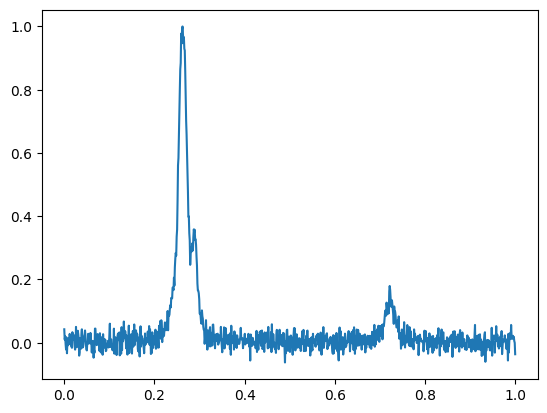

In [ ]:
parameters = {
    "center_range": (0, 1),
    "amplitude_range": (0.01, 1),
    "gamma_range": (0.001, 0.02),
    "x_min": 0,
    "x_max": 1
}

x_0, y_0, params_0 = generateCurve(parameters, 4, 1000, 0.05)
plt.plot(x_0,y_0)

In [ ]:
parameters = {
    "center_range": (0, 1),
    "amplitude_range": (0.01, 1),
    "gamma_range": (0.001, 0.02),
    "x_min": 0,
    "x_max": 1
}

fit_results, neighbors = knnFit(100000, parameters, x_0, y_0, k=5, rounds=1)

Round 1 starting...


In [ ]:
for peak in fit_results:
  print(peak)

{'peak_id': 3, 'center': np.float64(0.24131745742713537), 'amplitude': np.float64(0.38314628382709665), 'gamma': np.float64(0.012424710125001188)}
{'peak_id': 0, 'center': np.float64(0.2909373943676871), 'amplitude': np.float64(0.23534760934820564), 'gamma': np.float64(0.005627431143621851)}
{'peak_id': 2, 'center': np.float64(0.349878640112883), 'amplitude': np.float64(0.5883251092126476), 'gamma': np.float64(0.006493469742898607)}
{'peak_id': 1, 'center': np.float64(0.591868402928424), 'amplitude': np.float64(0.37130829264783094), 'gamma': np.float64(0.010654723501236604)}


In [ ]:
for param in params_0:
  print(param)

{'peak_id': 0, 'center': 0.2896788224717769, 'amplitude': 0.32525760043006713, 'gamma': 0.005997666176621345}
{'peak_id': 1, 'center': 0.2596334638337189, 'amplitude': 0.9640794030977169, 'gamma': 0.007999763204676553}
{'peak_id': 2, 'center': 0.26808667664851704, 'amplitude': 0.5667584771809202, 'gamma': 0.0061292603274711996}
{'peak_id': 3, 'center': 0.722451747745031, 'amplitude': 0.16825203558735669, 'gamma': 0.012447588148820108}


   TOP 5 NEAREST NEIGHBORS

Neighbor 1 | Euclidean Distance: 1.146568
  - Peak 0: x0=0.7192, max=0.2767, gamma=0.0072
  - Peak 1: x0=0.9461, max=0.0913, gamma=0.0086
  - Peak 2: x0=0.2627, max=0.6437, gamma=0.0060
  - Peak 3: x0=0.2624, max=0.8901, gamma=0.0192

Neighbor 2 | Euclidean Distance: 1.425495
  - Peak 0: x0=0.2388, max=0.1142, gamma=0.0026
  - Peak 1: x0=0.2620, max=0.9914, gamma=0.0114
  - Peak 2: x0=0.7010, max=0.3124, gamma=0.0019
  - Peak 3: x0=0.2304, max=0.1227, gamma=0.0054

Neighbor 3 | Euclidean Distance: 1.462396
  - Peak 0: x0=0.2556, max=0.6065, gamma=0.0062
  - Peak 1: x0=0.8708, max=0.1158, gamma=0.0072
  - Peak 2: x0=0.2644, max=0.7459, gamma=0.0148
  - Peak 3: x0=0.2835, max=0.0169, gamma=0.0108

Neighbor 4 | Euclidean Distance: 1.556283
  - Peak 0: x0=0.1514, max=0.0968, gamma=0.0065
  - Peak 1: x0=0.2797, max=0.4220, gamma=0.0128
  - Peak 2: x0=0.2591, max=0.7879, gamma=0.0059
  - Peak 3: x0=0.1692, max=0.0383, gamma=0.0082

Neighbor 5 | Euclidean Distance:

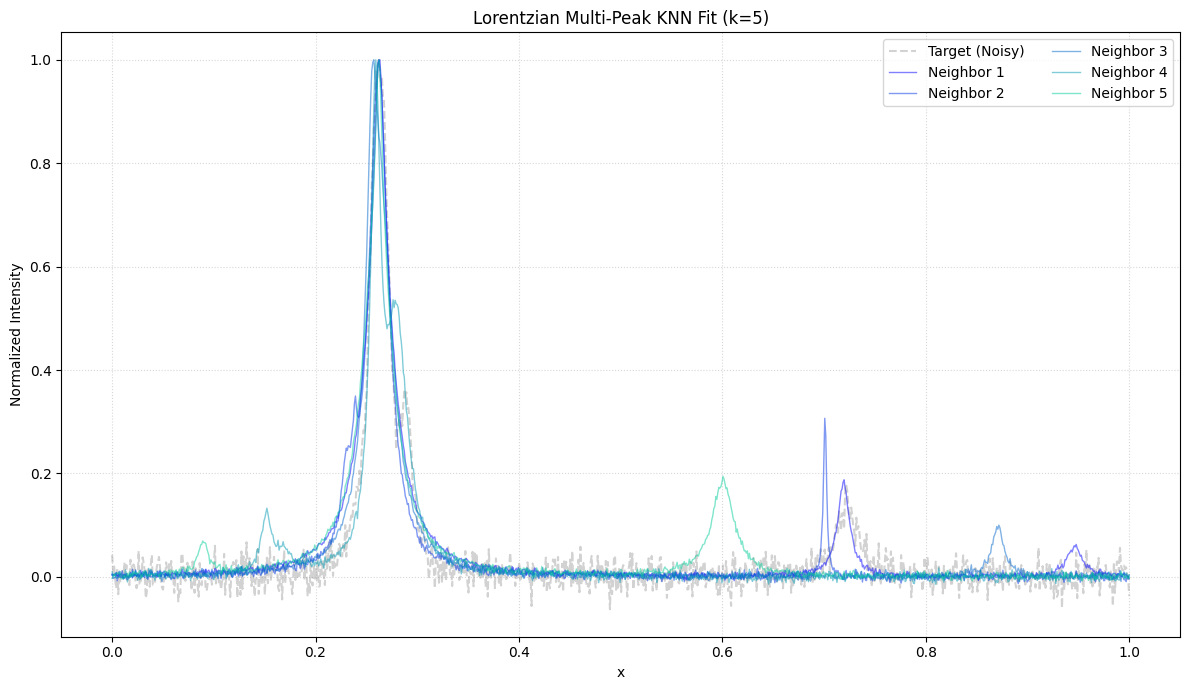

In [ ]:


# 2. Print Neighbor Details
print(f"{'='*30}")
print(f"   TOP {len(neighbors)} NEAREST NEIGHBORS") # Dynamic title
print(f"{'='*30}")
for i, n in enumerate(neighbors):
    print(f"\nNeighbor {i+1} | Euclidean Distance: {n['distance']:.6f}")
    for p in n["params"]:
        print(f"  - Peak {p['peak_id']}: x0={p['center']:.4f}, max={p['amplitude']:.4f}, gamma={p['gamma']:.4f}")

# 3. Reconstruct the curve
y_fit = np.zeros_like(x_0)
for peak in fit_results:
    y_fit += lorentzian(x_0, x0=peak["center"], gamma=peak["gamma"], maximum=peak["amplitude"])

if np.max(y_fit) > 0:
    y_fit /= np.max(y_fit)

# 4. Final Visualization
plt.figure(figsize=(12, 7))

# Plot the noisy target data
plt.plot(x_0, y_0, label="Target (Noisy)", alpha=0.35, color="gray", lw=1.5, linestyle="--")

# FIX: Use a colormap to avoid IndexError
# This creates a list of colors based on the number of neighbors
num_n = len(neighbors)
colors = [plt.cm.winter(i / num_n) for i in range(num_n)]

for i, n in enumerate(neighbors):
    plt.plot(n["x"], n["y"], color=colors[i], alpha=0.5, lw=1, label=f"Neighbor {i+1}")

# Plot the averaged result as a bold line
#plt.plot(x_0, y_fit, label="Averaged Fit Result", color="red", linewidth=2.5)

plt.title(f"Lorentzian Multi-Peak KNN Fit (k={len(neighbors)})")
plt.xlabel("x")
plt.ylabel("Normalized Intensity")
plt.legend(loc="upper right", ncol=2) # ncol=2 helps if the legend gets too long
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()